In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load clean data from Phase 2
clean_data = pd.read_csv('../data/clean_data.csv')

print("✅ Data loaded!")
print(f"Shape: {clean_data.shape}")
print(clean_data.head())

✅ Data loaded!
Shape: (100836, 5)
   userId  movieId  rating                        title  \
0       1        1     4.0             Toy Story (1995)   
1       1        3     4.0      Grumpier Old Men (1995)   
2       1        6     4.0                  Heat (1995)   
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [2]:
# Create the user-movie matrix
# Rows = users, Columns = movies, Values = ratings
user_movie_matrix = clean_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

print(f"Matrix shape: {user_movie_matrix.shape}")
print(f"Users:  {user_movie_matrix.shape[0]}")
print(f"Movies: {user_movie_matrix.shape[1]}")
print("\nSample (first 5 users, first 5 movies):")
print(user_movie_matrix.iloc[:5, :5])

Matrix shape: (610, 9719)
Users:  610
Movies: 9719

Sample (first 5 users, first 5 movies):
title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1              NaN                                      NaN   
2              NaN                                      NaN   
3              NaN                                      NaN   
4              NaN                                      NaN   
5              NaN                                      NaN   

title   'Round Midnight (1986)  'Salem's Lot (2004)  'Til There Was You (1997)  
userId                                                                          
1                          NaN                  NaN                        NaN  
2                          NaN                  NaN                        NaN  
3                          NaN                  NaN                        NaN  
4                          NaN                  NaN          

In [3]:
total_cells  = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]
filled_cells = user_movie_matrix.count().sum()
sparsity     = (1 - filled_cells / total_cells) * 100

print(f"Total cells:   {total_cells:,}")
print(f"Filled cells:  {filled_cells:,}")
print(f"Empty cells:   {total_cells - filled_cells:,}")
print(f"Sparsity:      {sparsity:.2f}%")
print("\nThis is expected — most users haven't rated most movies.")

Total cells:   5,928,590
Filled cells:  100,832
Empty cells:   5,827,758
Sparsity:      98.30%

This is expected — most users haven't rated most movies.


In [4]:
# Fill NaN with 0 (not rated)
matrix_filled = user_movie_matrix.fillna(0)

# Transpose so we compare movies vs movies (not users)
movie_similarity = cosine_similarity(matrix_filled.T)

# Wrap in a dataframe with movie titles
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

print(f"✅ Similarity matrix computed!")
print(f"Shape: {movie_similarity_df.shape}")
print("\nTop similar movies to 'Toy Story (1995)':")
print(
    movie_similarity_df['Toy Story (1995)']
    .sort_values(ascending=False)
    .head(10)
)

✅ Similarity matrix computed!
Shape: (9719, 9719)

Top similar movies to 'Toy Story (1995)':
title
Toy Story (1995)                                     1.000000
Toy Story 2 (1999)                                   0.572601
Jurassic Park (1993)                                 0.565637
Independence Day (a.k.a. ID4) (1996)                 0.564262
Star Wars: Episode IV - A New Hope (1977)            0.557388
Forrest Gump (1994)                                  0.547096
Lion King, The (1994)                                0.541145
Star Wars: Episode VI - Return of the Jedi (1983)    0.541089
Mission: Impossible (1996)                           0.538913
Groundhog Day (1993)                                 0.534169
Name: Toy Story (1995), dtype: float64


In [5]:
def collaborative_recommend(movie_title, n_recommendations=10):
    """
    Given a movie title, return top N similar movies
    based on collaborative filtering.
    """
    if movie_title not in movie_similarity_df.columns:
        print(f"❌ '{movie_title}' not found.")
        print("Check the exact title and year e.g. 'Toy Story (1995)'")
        return None

    # Get similarity scores and drop the movie itself
    sim_scores = (
        movie_similarity_df[movie_title]
        .sort_values(ascending=False)
        .drop(movie_title)
        .head(n_recommendations)
    )

    print(f"\n🎬 Movies similar to '{movie_title}':")
    print("-" * 55)
    for i, (title, score) in enumerate(sim_scores.items(), 1):
        print(f"{i:2}. {title:<45} (score: {score:.4f})")

    return sim_scores

In [6]:
collaborative_recommend('Toy Story (1995)')


🎬 Movies similar to 'Toy Story (1995)':
-------------------------------------------------------
 1. Toy Story 2 (1999)                            (score: 0.5726)
 2. Jurassic Park (1993)                          (score: 0.5656)
 3. Independence Day (a.k.a. ID4) (1996)          (score: 0.5643)
 4. Star Wars: Episode IV - A New Hope (1977)     (score: 0.5574)
 5. Forrest Gump (1994)                           (score: 0.5471)
 6. Lion King, The (1994)                         (score: 0.5411)
 7. Star Wars: Episode VI - Return of the Jedi (1983) (score: 0.5411)
 8. Mission: Impossible (1996)                    (score: 0.5389)
 9. Groundhog Day (1993)                          (score: 0.5342)
10. Back to the Future (1985)                     (score: 0.5304)


title
Toy Story 2 (1999)                                   0.572601
Jurassic Park (1993)                                 0.565637
Independence Day (a.k.a. ID4) (1996)                 0.564262
Star Wars: Episode IV - A New Hope (1977)            0.557388
Forrest Gump (1994)                                  0.547096
Lion King, The (1994)                                0.541145
Star Wars: Episode VI - Return of the Jedi (1983)    0.541089
Mission: Impossible (1996)                           0.538913
Groundhog Day (1993)                                 0.534169
Back to the Future (1985)                            0.530381
Name: Toy Story (1995), dtype: float64

In [7]:
collaborative_recommend('Forrest Gump (1994)')


🎬 Movies similar to 'Forrest Gump (1994)':
-------------------------------------------------------
 1. Shawshank Redemption, The (1994)              (score: 0.7130)
 2. Jurassic Park (1993)                          (score: 0.6883)
 3. Pulp Fiction (1994)                           (score: 0.6855)
 4. Braveheart (1995)                             (score: 0.6431)
 5. Silence of the Lambs, The (1991)              (score: 0.6395)
 6. Apollo 13 (1995)                              (score: 0.6276)
 7. Matrix, The (1999)                            (score: 0.6099)
 8. Mrs. Doubtfire (1993)                         (score: 0.6080)
 9. Schindler's List (1993)                       (score: 0.6021)
10. Terminator 2: Judgment Day (1991)             (score: 0.6009)


title
Shawshank Redemption, The (1994)     0.712993
Jurassic Park (1993)                 0.688259
Pulp Fiction (1994)                  0.685544
Braveheart (1995)                    0.643090
Silence of the Lambs, The (1991)     0.639463
Apollo 13 (1995)                     0.627559
Matrix, The (1999)                   0.609935
Mrs. Doubtfire (1993)                0.607983
Schindler's List (1993)              0.602072
Terminator 2: Judgment Day (1991)    0.600886
Name: Forrest Gump (1994), dtype: float64

In [8]:
collaborative_recommend('The Dark Knight (2008)')

❌ 'The Dark Knight (2008)' not found.
Check the exact title and year e.g. 'Toy Story (1995)'


In [9]:
# Search for movies containing a keyword
keyword = 'Dark'
matches = [title for title in movie_similarity_df.columns if keyword.lower() in title.lower()]
print(f"Movies containing '{keyword}':")
for m in matches[:15]:
    print(f"  {m}")

Movies containing 'Dark':
  Alone in the Dark (2005)
  Alone in the Dark II (2008)
  Army of Darkness (1993)
  Babylon 5: The Lost Tales - Voices in the Dark (2007)
  Batman: The Dark Knight Returns, Part 1 (2012)
  Batman: The Dark Knight Returns, Part 2 (2013)
  Black Tar Heroin: The Dark End of the Street (2000)
  Bloodsport: The Dark Kumite (1999)
  Cry in the Dark, A (1988)
  Dancer in the Dark (2000)
  Dark Blue (2003)
  Dark Blue World (Tmavomodrý svet) (2001)
  Dark City (1998)
  Dark Crystal, The (1982)
  Dark Days (2000)


In [10]:
# Try other keywords
for keyword in ['Matrix', 'Batman', 'Spider', 'Lord', 'Star Wars']:
    matches = [t for t in movie_similarity_df.columns if keyword.lower() in t.lower()]
    if matches:
        print(f"\n'{keyword}' matches:")
        for m in matches[:3]:
            print(f"  {m}")


'Matrix' matches:
  Animatrix, The (2003)
  Matrix Reloaded, The (2003)
  Matrix Revolutions, The (2003)

'Batman' matches:
  Batman & Robin (1997)
  Batman (1966)
  Batman (1989)

'Spider' matches:
  Along Came a Spider (2001)
  Amazing Spider-Man, The (2012)
  Giant Spider Invasion, The (1975)

'Lord' matches:
  Dragon Lord (a.k.a. Dragon Strike) (Long Xiao Ye) (1982)
  Dragon ball Z 04: Lord Slug (1991)
  Little Lord Fauntleroy (1936)

'Star Wars' matches:
  Empire of Dreams: The Story of the 'Star Wars' Trilogy (2004)
  Rogue One: A Star Wars Story (2016)
  Solo: A Star Wars Story (2018)


In [11]:
collaborative_recommend('The Dark Knight (2008)')

❌ 'The Dark Knight (2008)' not found.
Check the exact title and year e.g. 'Toy Story (1995)'


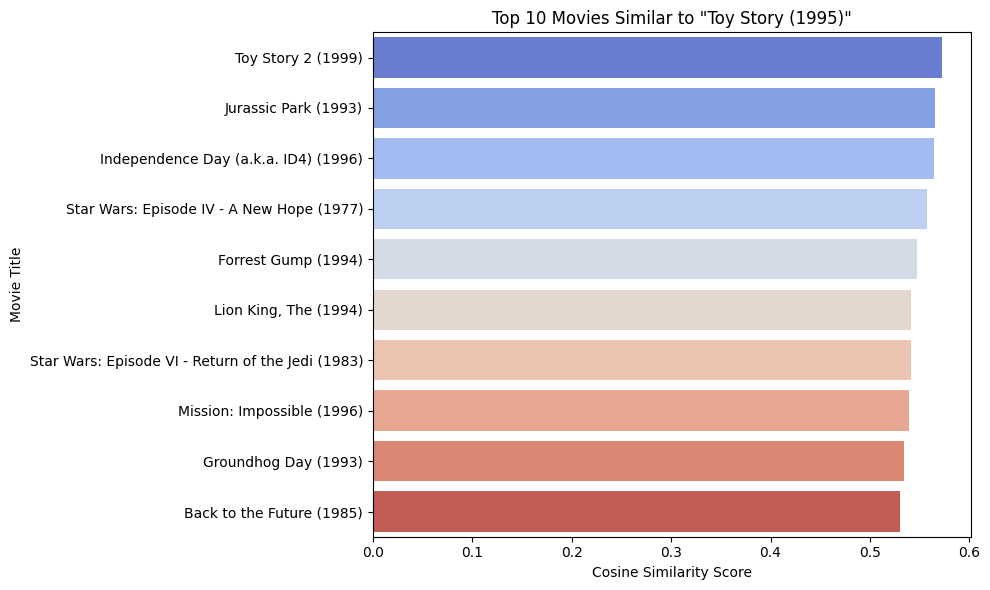

In [12]:
def plot_similarity(movie_title, n=10):
    scores = (
        movie_similarity_df[movie_title]
        .sort_values(ascending=False)
        .drop(movie_title)
        .head(n)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(x=scores.values, y=scores.index, palette='coolwarm')
    plt.title(f'Top {n} Movies Similar to "{movie_title}"')
    plt.xlabel('Cosine Similarity Score')
    plt.ylabel('Movie Title')
    plt.tight_layout()
    plt.savefig('../data/collab_similarity.png')
    plt.show()

plot_similarity('Toy Story (1995)')

In [13]:
# Split into train and test
train_data, test_data = train_test_split(
    clean_data, test_size=0.2, random_state=42
)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples:  {len(test_data)}")

# Build matrix from training data only
train_matrix = train_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
).fillna(0)

# Compute similarity on training data
train_similarity = cosine_similarity(train_matrix.T)
train_similarity_df = pd.DataFrame(
    train_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)

def predict_rating(user_id, movie_title, train_mat, sim_df, n=10):
    """Predict what rating a user would give a movie."""
    global_mean = train_mat.values[train_mat.values != 0].mean()

    if movie_title not in sim_df.columns:
        return global_mean
    if user_id not in train_mat.index:
        return global_mean

    similar_movies = sim_df[movie_title].drop(movie_title)
    user_ratings   = train_mat.loc[user_id]
    rated          = user_ratings[user_ratings > 0]
    common         = similar_movies[similar_movies.index.isin(rated.index)]

    if len(common) == 0:
        return global_mean

    top           = common.nlargest(n)
    weighted_sum  = sum(top[m] * rated[m] for m in top.index)
    similarity_sum = top.abs().sum()

    if similarity_sum == 0:
        return global_mean

    return weighted_sum / similarity_sum

print("✅ Prediction function ready!")

Training samples: 80668
Testing samples:  20168
✅ Prediction function ready!


In [14]:
# Sample 500 rows from test data for speed
test_sample = test_data.sample(500, random_state=42)

actuals     = []
predictions = []

for _, row in test_sample.iterrows():
    predicted = predict_rating(
        row['userId'],
        row['title'],
        train_matrix,
        train_similarity_df
    )
    actuals.append(row['rating'])
    predictions.append(predicted)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"✅ Collaborative Filtering RMSE: {rmse:.4f}")
print("\nInterpretation:")
print(f"  Below 1.0 = Good ✅")
print(f"  Your model: {'Good ✅' if rmse < 1.0 else 'Needs improvement ⚠️'}")

✅ Collaborative Filtering RMSE: 0.8712

Interpretation:
  Below 1.0 = Good ✅
  Your model: Good ✅


In [15]:
import os
os.makedirs('../models', exist_ok=True)

# Save similarity matrix
with open('../models/collab_similarity.pkl', 'wb') as f:
    pickle.dump(movie_similarity_df, f)

# Save user-movie matrix
with open('../models/user_movie_matrix.pkl', 'wb') as f:
    pickle.dump(user_movie_matrix, f)

print("✅ Models saved!")
print("   - models/collab_similarity.pkl")
print("   - models/user_movie_matrix.pkl")

✅ Models saved!
   - models/collab_similarity.pkl
   - models/user_movie_matrix.pkl
